<h2> UNE discrétisation du DSM : le modèle DDPM</h2>

DDPM équivaut à une SDE à variance conservée (VP SDE) avec un bruitage contrôlé

Imports

In [3]:
import torch
import torchvision
from matplotlib import pyplot as plt
from sympy.abc import sigma
from tqdm.notebook import tqdm
from torch import nn, optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np

Chargement des données

In [12]:
TRANSFORMS = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

ds = torchvision.datasets.MNIST("/tmp/mnist", train=True, transform=TRANSFORMS, target_transform=None, download=True)

batch_size = 128
input_size = 784 #32*32 #for CIFAR10

dataloader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)


Construction de réseau de neurone

In [5]:
# version 1 : réseau au feeling

net = nn.Sequential(nn.Linear(input_size+1, 512),
                    nn.ReLU(),
                    nn.Linear(512, 128),
                    nn.ReLU(),
                    nn.Linear(128, 1),)

optimizer = optim.Adam(net.parameters(), lr=0.001)


In [13]:
# version 2 : UNET basique

class SimpleUNet(nn.Module):
    def __init__(self, input=1, output=1):
        super(SimpleUNet, self).__init__()
        self.encoder = torch.nn.ModuleList(
            [
                nn.Conv2d(input, out_channels=32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ]
        )
        
        self.decoder = torch.nn.ModuleList(
            [
                nn.Conv2d(64, out_channels=64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, output, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.SiLU()  # The activation function



    def forward(self, x):
        h = []
        for i, l in enumerate(self.encoder):
            x = self.act(l(x))  # Through the layer and the activation function
            if i < 2:  # For all but the third (final) down layer:
                h.append(x)  # Storing output for skip connection

        for i, l in enumerate(self.decoder):
            if i > 0:  # For all except the first up layer
                x += h.pop()  # Fetching stored output (skip connection)
            x = self.act(l(x))  # Through the layer and the activation function

        return x

torch.Size([128, 1, 28, 28])
torch.Size([128, 1, 28, 28])


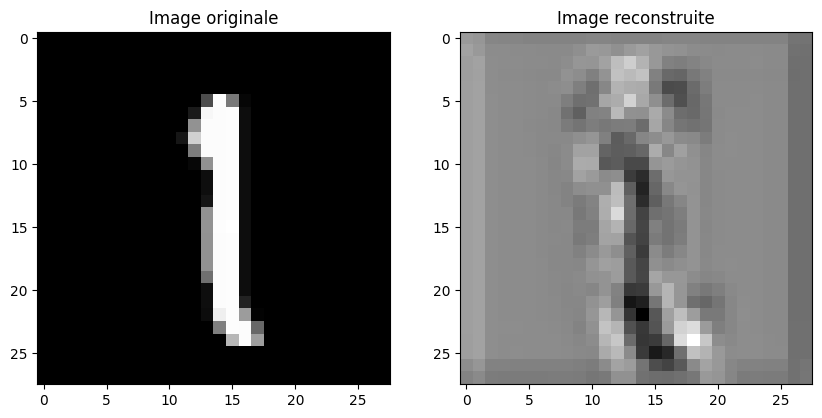

In [14]:
data_iter = iter(dataloader)
x, y = next(data_iter)
print(x.shape) 
unet = SimpleUNet()
x_u = unet(x)
print(x_u.shape)
fig, axe = plt.subplots(1, 2, figsize=(10, 5))
axe[0].set_title("Image originale")
axe[0].imshow(x[0, 0].numpy(), cmap="gray")
axe[1].set_title("Image reconstruite") # par Unet
axe[1].imshow(x_u[0, 0].detach().numpy(), cmap="gray")

In [11]:
class ResetDataset:
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_iter = iter(self.images)
        image, _ = image_iter[idx]
        if self.transform:
            if not isinstance(image, torch.Tensor):
                image = self.transform(image)
        return image
    
unet = SimpleUNet()
dataloader = ResetDataset(dataloader,transform=TRANSFORMS)
x, y = next(iter(dataloader))
x_u = unet(x)
print(x_u.shape)
plt.imshow(x_u[0, 0].detach().numpy(), cmap="gray")

TypeError: '_SingleProcessDataLoaderIter' object is not subscriptable

Générateur

In [32]:
T = 1000
beta = torch.linspace(10*1e-4, 0.02, steps=T) # choix inspiré par Ho et al.
alpha = torch.cumprod(1-beta, dim=0)
e_dist = torch.distributions.normal.Normal(0, 1)


def generate(nb_samples=1):
    for _ in range(nb_samples):
        X = e_dist.sample([input_size])
        for t in reversed(range(T)):
            t = torch.as_tensor([t])
            Zt = e_dist.sample([input_size])
            in_tensor_ = torch.cat((X, t), dim=0)
            X = 1/((1-beta[t]).sqrt()) * (X - (beta[t]/((1-alpha[t]).sqrt()))*net(in_tensor_)) + beta[t]*Zt

        img = X.detach().numpy().reshape(28,28)
        plt.figure(figsize=(2,2))
        plt.imshow(img, cmap='gray')
        plt.show()

    plt.show()



Entraînement

Epoch 0/100:   0%|          | 0/468 [00:00<?, ?it/s]

C:\Users\mmnb6\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([128, 1, 1, 1])) that is different to the input size (torch.Size([128, 784])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


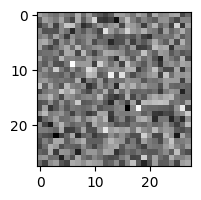

Epoch 1/100:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 5/100:   0%|          | 0/468 [00:00<?, ?it/s]

...

Epoch 95/100:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 96/100:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 97/100:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/468 [00:00<?, ?it/s]

In [16]:
nb_epochs = 100
criterion = nn.MSELoss()

for epoch in range(nb_epochs):
    for X0, _ in tqdm(dataloader, desc=f"Epoch {epoch}/{nb_epochs}"):

        X0 = torch.flatten(X0.squeeze(), 1, 2) # -> [batchsize, 784]
        e = e_dist.sample([batch_size, input_size])
        t = torch.randint(1, T, size=[batch_size, 1])
        
        Xt = alpha[t].sqrt() * X0 + (1-alpha[t]).sqrt() * e
        in_tensor = torch.concat([Xt, t], dim=1)

        #print("Xt shape:", Xt.shape)
        #print("t shape:", t.shape)
        #print("in_tensor shape:", in_tensor.shape)
        #print("e shape:", e.shape)
        in_tensor = in_tensor.reshape([128, 785, 1, 1])

        #print("in_tensor shape après reshaping:", in_tensor.shape)
        model = SimpleUNet(input=785, output=1)
        e_theta = model(in_tensor)
        loss = criterion(e, e_theta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % (nb_epochs+10//10) == 0:
        generate()

In [ ]:
input_tensor = torch.randn(batch_size, 785, 1, 1)  # Tenseur d'entrée

model = SimpleUNet(input=785, output=1)
output = model(input_tensor)

print("Output shape:", output.shape)



Output shape: torch.Size([128, 1, 1, 1])


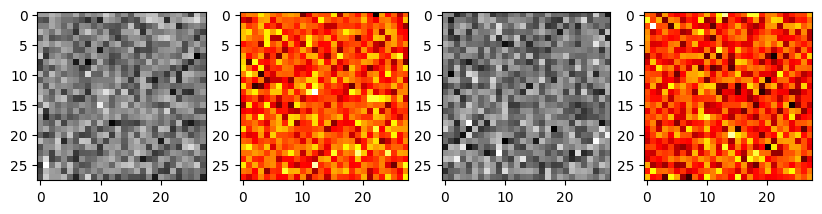

In [51]:
def generate_tensor(nb_samples=1):
    for _ in range(nb_samples):
        X = e_dist.sample([input_size])
        for t in reversed(range(T)):
            t = torch.as_tensor([t])
            Zt = e_dist.sample([input_size])
            in_tensor_ = torch.cat((X, t), dim=0)
            X = 1/((1-beta[t]).sqrt()) * (X - (beta[t]/((1-alpha[t]).sqrt()))*net(in_tensor_)) + beta[t]*Zt

        img = X.detach().numpy().reshape(28,28)
        return img
fig, axe = plt.subplots(1, 4, figsize=(10, 5))
axe[0].imshow(generate_tensor(1), cmap="gray")
axe[1].imshow(generate_tensor(1), cmap="hot")
axe[2].imshow(generate_tensor(1), cmap="gray")
axe[3].imshow(generate_tensor(1), cmap="hot")

Sur le dataset CIFAR

In [27]:
TRANSFORMS2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # Normalisation
])
chemin = "./cifar-10-batches-py"
dataset = torchvision.datasets.CIFAR10(root=chemin, train=False, transform=TRANSFORMS2, download=False)

batch_size = 128
input_size = 32*32 #for CIFAR10

dataloader_cifar = DataLoader(torch.vision, batch_size=batch_size, shuffle=True, drop_last=F)

RuntimeError: Dataset not found or corrupted. You can use download=True to download it

In [ ]:
dataloader_cifar_iter = iter(dataloader_cifar)
x, y = next(dataloader_cifar_iter)
print(x.shape) 
unet = SimpleUNet(input=3, output=3)
x_u = unet(x)
print(x_u.shape)
fig, axe = plt.subplots(1, 2, figsize=(10, 5))
axe[0].set_title("Image originale")
axe[0].imshow(x[0, 0].numpy())
axe[1].set_title("Image reconstruite") # par Unet
axe[1].imshow(x_u[0, 0].detach().numpy())

In [ ]:
nb_epochs = 1
criterion = nn.MSELoss()

for epoch in range(nb_epochs):
    for X0, _ in tqdm(dataloader_cifar, desc=f"Epoch {epoch}/{nb_epochs}"):

        X0 = torch.flatten(X0.squeeze(), 1, 2) # -> [batchsize, 784]
        e = e_dist.sample([batch_size, input_size])
        t = torch.randint(1, T, size=[batch_size, 1])
        
        Xt = alpha[t].sqrt() * X0 + (1-alpha[t]).sqrt() * e
        in_tensor = torch.concat([Xt, t], dim=1)

        #print("Xt shape:", Xt.shape)
        #print("t shape:", t.shape)
        #print("in_tensor shape:", in_tensor.shape)
        #print("e shape:", e.shape)
        in_tensor = in_tensor.reshape([128, 785, 1, 1])

        #print("in_tensor shape après reshaping:", in_tensor.shape)
        model = SimpleUNet(input=785, output=1)
        e_theta = model(in_tensor)
        loss = criterion(e, e_theta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % (nb_epochs+10//10) == 0:
        generate()
